Understanding DICOM data - Metadata, Visualization and Nomenclature  

In [1]:
from pathlib import Path
import collections
import os
import pydicom

def is_dicom(path: Path) -> bool:
    # fast sniff: "DICM" at byte offset 128 (common but not guaranteed)
    try:
        with open(path, "rb") as fp:
            fp.seek(128)
            return fp.read(4) == b"DICM"
    except OSError:
        return False

def find_dicom_series(root_or_files):
    """
    Accept either:
      - a folder path (walk recursively), OR
      - an iterable of file paths
    Return: dict[SeriesInstanceUID] -> list[Path]
    """
    series = collections.defaultdict(list)

    if isinstance(root_or_files, (str, os.PathLike, Path)):
        root = Path(root_or_files)
        it = (p for p in root.rglob("*") if p.is_file())
    else:
        it = (Path(p) for p in root_or_files)

    for f in it:
        if not f.is_file():
            continue
        if not is_dicom(f):
            continue

        try:
            ds = pydicom.dcmread(f, stop_before_pixels=True, force=True)
        except Exception:
            continue

        uid = ds.get("SeriesInstanceUID") or ds.get("SOPInstanceUID")
        series[str(uid)].append(f)

    return series

In [5]:
series = find_dicom_series(r"/data0/markok/data_pet/PET_CT_brain_UKC_Nevro/Gasper_cetrti_paket/")

for uid, files in series.items():
        # Read one file to get series metadata (series are similar, processing time is longer for all, so we can just read one)
        ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
        print(f"Series UID: {uid}")
        print(f"Study Instance UID: {getattr(ds, 'StudyInstanceUID', 'N/A')}")
        print(f"Number of files: {len(files)}")
        print(f"Modality: {getattr(ds, 'Modality', 'N/A')}")
        print(f"Series Description: {getattr(ds, 'SeriesDescription', 'N/A')}")
        print(f"Patient ID: {getattr(ds, 'PatientID', 'N/A')}")
        print("---")


Series UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000010
Study Instance UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000006
Number of files: 148
Modality: CT
Series Description: AC   CT Brain  3.0  Hf38
Patient ID: 
---
Series UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000616
Study Instance UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000461
Number of files: 148
Modality: PT
Series Description: PET Brain uncorrected
Patient ID: 
---
Series UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000162
Study Instance UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000006
Number of files: 148
Modality: PT
Series Description: PET Brain
Patient ID: 
---
Series UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000312
Study Instance UID: 1.3.12.2.1107.5.8.15.132326.30000025090515440342500000006
Number of files: 148
Modality: PT
Series Description: PET Brain uncorrected
Patient ID: 
---
Series UID: 1.3.12.2.1107.5.8.15.132326.30000

In [ ]:
print(series.keys())

AttributeError: 'collections.defaultdict' object has no attribute 'uid'

Each series contains 148 files, and each file is a different slice of the brain, taken upon patient imaging. 

Next step is to separate the series per patient, based on their unique Study instance

In [8]:
def group_series_by_patient(series_dict):
    """
    series_dict : {SeriesUID: [filepaths]}
    returns     : {PatientKey: {StudyUID: [SeriesUID, ...]}}
    """
    patients = collections.defaultdict(lambda: collections.defaultdict(list))

    for series_uid, files in series_dict.items():
        if not files:
            print(f"[WARN] No files for series {series_uid}, skipping.")
            continue

        try:
            ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
        except Exception as e:
            print(f"[WARN] Could not read {files[0]}: {e}")
            continue

        def safe_get(tag):
            val = getattr(ds, tag, None)
            return val if val not in (None, "", " ") else None

        # Stable patient key, robust to anonymisation
        date  = getattr(ds, "StudyDate", "NODATE")
        time  = getattr(ds, "StudyTime", "000000")[:6]
        patient_key = (
            safe_get("PatientID") or #usually empty due to anonymisation
            safe_get("StudyInstanceUID") or #usually this one
            f"{date}_{time}"
        )
        
        study_uid = safe_get("StudyInstanceUID")
        if study_uid is None:
            print(f"[WARN] Missing StudyInstanceUID for series {series_uid}, skipping.")
            continue

        patients[patient_key][study_uid].append(series_uid)

    return patients


Found 278 patients


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:


patients = group_series_by_patient(series)
print(f"Found {len(patients)} patients")
p_idx = 0
for pat_nr, (patient_key, studies) in enumerate(patients.items(), start=1):
    print(f"Patient {pat_nr}: {patient_key} | Study count: {len(studies)}")
    for modality, study_des in studies.items():
        print(f"  Study: {modality} | Series count: {len(study_des)}")

In [ ]:

# ── 3. Extract pixel data & apply rescale ────────────────────────────────────

def to_hu(ds):
    """Convert raw pixel values to Hounsfield Units."""
    pixels = ds.pixel_array.astype(np.float32)
    slope  = float(getattr(ds, "RescaleSlope",  1))
    inter  = float(getattr(ds, "RescaleIntercept", 0))
    return pixels * slope + inter

hu_slices = [to_hu(ds) for ds in slices]

# Stack into a 3-D volume: shape (num_slices, rows, cols)
volume = np.stack(hu_slices, axis=0)
print(volume.shape, volume.dtype)   # e.g. (4, 512, 512)
print(f"HU range: {volume.min():.0f} … {volume.max():.0f}")



NameError: name 'slices' is not defined

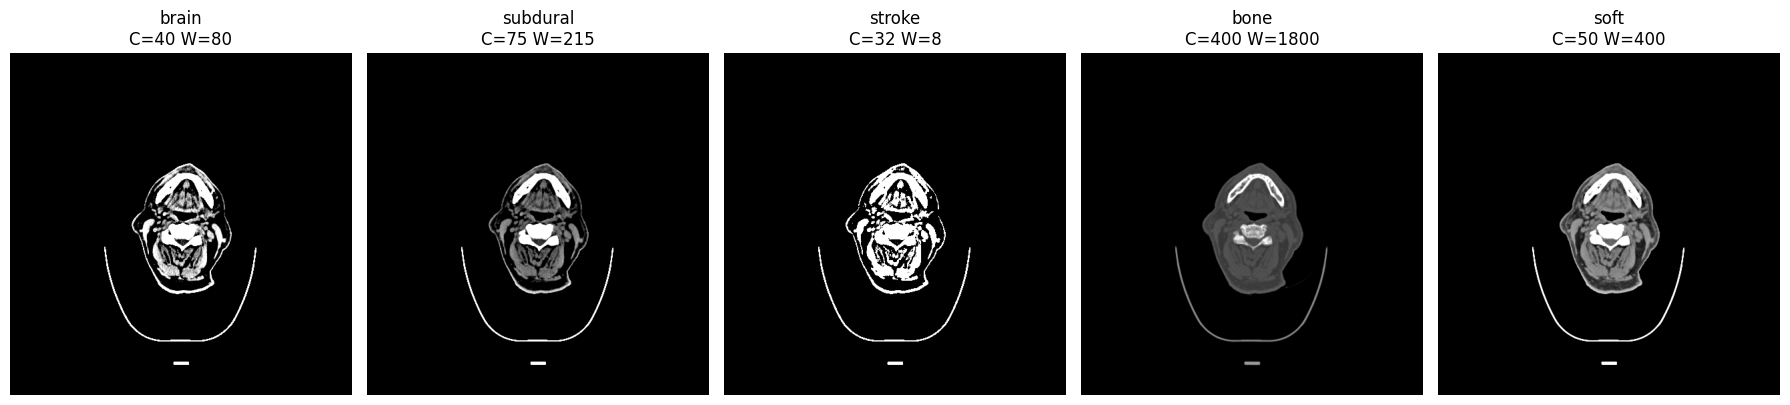

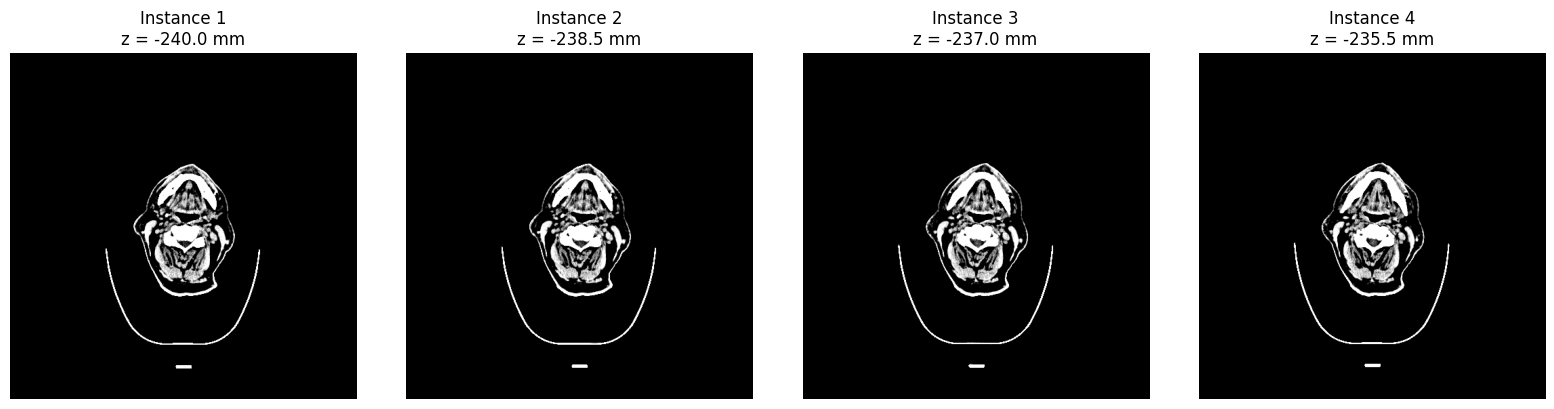

In [ ]:

# ── 4. Windowing (display contrast) ─────────────────────────────────────────

def apply_window(image_hu, center, width):
    lo = center - width / 2
    hi = center + width / 2
    return np.clip((image_hu - lo) / (hi - lo), 0, 1)

# Common CT windows
WINDOWS = {
    "brain":    (40,   80),
    "subdural": (75,  215),
    "stroke":   (32,   8),
    "bone":     (400, 1800),
    "soft":     (50,  400),
}

fig, axes = plt.subplots(1, len(WINDOWS), figsize=(18, 4))
for ax, (name, (c, w)) in zip(axes, WINDOWS.items()):
    ax.imshow(apply_window(hu_slices[0], c, w), cmap="gray", origin="upper")
    ax.set_title(f"{name}\nC={c} W={w}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("windows.png", dpi=150)
plt.show()


# ── 5. View all four slices ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, ds, hu in zip(axes, slices, hu_slices):
    ax.imshow(apply_window(hu, 40, 80), cmap="gray", origin="upper")
    ax.set_title(f"Instance {ds.InstanceNumber}\nz = {float(ds.SliceLocation):.1f} mm")
    ax.axis("off")
plt.tight_layout()
plt.savefig("slices.png", dpi=150)
plt.show()



In [ ]:

# ── 6. Pixel statistics per slice ────────────────────────────────────────────

for ds, hu in zip(slices, hu_slices):
    mask_tissue = (hu > -100) & (hu < 200)     # rough soft-tissue mask
    print(f"Slice {ds.InstanceNumber}  z={float(ds.SliceLocation):.1f} mm  "
          f"mean={hu[mask_tissue].mean():.1f} HU  "
          f"std={hu[mask_tissue].std():.1f} HU")


# ── 7. Simple threshold segmentation ─────────────────────────────────────────

def segment(hu, lo, hi):
    return ((hu >= lo) & (hu <= hi)).astype(np.uint8)

bone_mask  = segment(volume, 200, 3000)
brain_mask = segment(volume, 20,  80)
air_mask   = segment(volume, -1000, -500)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (hu, bm, brm) in enumerate(zip(hu_slices, bone_mask, brain_mask)):
    axes[0, i].imshow(apply_window(hu, 400, 1800), cmap="gray", origin="upper")
    axes[0, i].contour(bm, colors="yellow", linewidths=0.5)
    axes[0, i].set_title(f"Bone window + mask")
    axes[0, i].axis("off")

    axes[1, i].imshow(apply_window(hu, 40, 80), cmap="gray", origin="upper")
    axes[1, i].contour(brm, colors="cyan", linewidths=0.5)
    axes[1, i].set_title(f"Brain window + mask")
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig("segmentation.png", dpi=150)
plt.show()


# ── 8. Build a proper voxel spacing array ────────────────────────────────────

row_sp, col_sp = [float(x) for x in slices[0].PixelSpacing]
locations = [float(ds.SliceLocation) for ds in slices]
slice_sp = abs(locations[1] - locations[0])           # 1.5 mm here

voxel_spacing = np.array([slice_sp, row_sp, col_sp])  # (z, y, x) in mm
print(f"Voxel spacing (z,y,x): {voxel_spacing} mm")


# ── 9. Save modified DICOM (e.g. after processing) ───────────────────────────

import copy

def save_modified_dicom(original_ds, new_pixel_array_hu, out_path):
    ds = copy.deepcopy(original_ds)
    slope = float(getattr(ds, "RescaleSlope", 1))
    inter = float(getattr(ds, "RescaleIntercept", 0))
    raw = ((new_pixel_array_hu - inter) / slope).astype(np.int16)
    ds.PixelData = raw.tobytes()
    ds.save_as(out_path)

# Example: save slice 0 unchanged
save_modified_dicom(slices[0], hu_slices[0], "output_slice0.dcm")


# ── 10. Export as PNG ─────────────────────────────────────────────────────────

from PIL import Image

for ds, hu in zip(slices, hu_slices):
    windowed = apply_window(hu, 40, 80)
    img = Image.fromarray((windowed * 255).astype(np.uint8))
    img.save(f"slice_{ds.InstanceNumber:03d}.png")